# 🩻 Día 2 — Segmentación de Radiografías Térmicas con MedSAM

## 📋 Descripción del Proyecto

Este notebook implementa la **segmentación automática de dedos en radiografías térmicas** utilizando el modelo **MedSAM (Medical Segment Anything Model)**.

### 🎯 Objetivos

1. ✅ Cargar y procesar 70 radiografías térmicas
2. ✅ Detectar automáticamente la región de interés (dedo)
3. ✅ Generar máscaras de segmentación de alta calidad
4. ✅ Evaluar la confianza de cada segmentación
5. ✅ Visualizar resultados con gráficos estadísticos
6. ✅ Documentar hallazgos y casos críticos

### 📊 Dataset

- **Total de imágenes**: 70
- **Estructura**: 
  - `train/si`: 25 imágenes
  - `train/no`: 10 imágenes
  - `test/si`: 20 imágenes
  - `test/no`: 15 imágenes
- **Formato**: PNG (640×480 px)
- **Tipo**: Radiografía térmica (infrarroja)

### 🔧 Tecnologías

- **Modelo**: MedSAM ViT-B (Vision Transformer Base)
- **Framework**: PyTorch + Segment Anything
- **Procesamiento**: OpenCV + NumPy
- **Visualización**: Matplotlib + Seaborn


## 1️⃣ Instalación de Dependencias

In [1]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python scikit-image tqdm
print("✅ Dependencias instaladas correctamente")


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Dependencias instaladas correctamente



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2️⃣ Importación de Librerías

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import cv2
from pathlib import Path
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor
import csv
from datetime import datetime
from collections import defaultdict

# Configurar estilo de gráficos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Librerías importadas correctamente")
print(f"   PyTorch: {torch.__version__}")
print(f"   NumPy: {np.__version__}")

✅ Librerías importadas correctamente
   PyTorch: 2.11.0+cpu
   NumPy: 2.4.4


## 3️⃣ Configuración Inicial

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Dispositivo: {device.upper()}")

checkpoint_path = "./Dia2/medsam_vit_b.pth"
current_dir = Path(os.getcwd())
cnn_folder = None

for parent in [current_dir] + list(current_dir.parents):
    potential_path = parent / "CNN_desde_0" / "imagenes_procesadas"
    if potential_path.exists():
        cnn_folder = potential_path
        break

input_dir = str(cnn_folder) if cnn_folder else "../CNN_desde_0/imagenes_procesadas"
output_dir = "./mascaras_segmentadas_todas"

Path(output_dir).mkdir(parents=True, exist_ok=True)

print(f"📁 Entrada: {input_dir}")
print(f"📁 Salida: {output_dir}")
print(f"✅ Configuración completada")

🖥️  Dispositivo: CPU
📁 Entrada: c:\Users\carlo\Desktop\Proyecte_RX\ProyectoFinal_CSEBDIA\CNN_desde_0\imagenes_procesadas
📁 Salida: ./mascaras_segmentadas_todas
✅ Configuración completada


## 4️⃣ Cargar Modelo MedSAM

In [8]:
# Configurar rutas relativas desde MedSAM_GeminiAPI/Dia2/
# El notebook debe estar en: ProyectoFinal_CSEBDIA/MedSAM_GeminiAPI/Dia2/

# Ruta del modelo preentrenado (está en ../Dia1/)
checkpoint_path = "../Dia1/medsam_vit_b.pth"

# Ruta del dataset (está en ../../CNN_desde_0/)
input_dir = "../../CNN_desde_0/imagenes_procesadas"

# Carpeta de salida (se crea en ./mascaras_segmentadas_todas/)
output_dir = "./mascaras_segmentadas_todas"

# Crear carpeta de salida
Path(output_dir).mkdir(parents=True, exist_ok=True)

print("📁 CONFIGURACIÓN DE RUTAS")
print("   📂 Ubicación: ProyectoFinal_CSEBDIA/MedSAM_GeminiAPI/Dia2/")
print(f"   📂 Dataset: {input_dir}")
print(f"   📂 Salida: {output_dir}")
print(f"   📂 Modelo: {checkpoint_path}")

# Verificaciones
abs_input = Path(input_dir).resolve()
abs_checkpoint = Path(checkpoint_path).resolve()

print("\n🔍 VERIFICANDO RUTAS:")

if not abs_checkpoint.exists():
    print(f"❌ ERROR: Checkpoint no encontrado")
    print(f"   Buscado en: {abs_checkpoint}")
    print(f"   Asegúrate de que medsam_vit_b.pth esté en ../Dia1/")
else:
    print(f"✅ Checkpoint encontrado")
    print(f"   Ubicación: {abs_checkpoint}")

if not abs_input.exists():
    print(f"❌ ERROR: Carpeta de entrada no encontrada")
    print(f"   Buscado en: {abs_input}")
    print(f"   Asegúrate de que CNN_desde_0/ esté en ProyectoFinal_CSEBDIA/")
else:
    print(f"✅ Carpeta de entrada encontrada")
    print(f"   Ubicación: {abs_input}")
    
    # Contar imágenes
    image_count = 0
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        image_count += len(list(Path(input_dir).rglob(ext)))
    print(f"   📸 Total de imágenes: {image_count}")

print(f"\n✅ Configuración completada correctamente")

import torch
from segment_anything import sam_model_registry, SamPredictor

print("⏳ Cargando modelo MedSAM...\n")

model_type = "vit_b"

# Crear modelo SIN checkpoint
medsam_model = sam_model_registry[model_type]()

# Cargar checkpoint manualmente
if os.path.exists(checkpoint_path):
    print(f"📂 Cargando checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    medsam_model.load_state_dict(checkpoint)
    print(f"✅ Checkpoint cargado")
else:
    print(f"❌ ERROR: Checkpoint no encontrado en {checkpoint_path}")

medsam_model = medsam_model.to(device)
medsam_model.eval()

print(f"✅ Modelo MedSAM cargado correctamente")
print(f"   Tipo: ViT-B")
print(f"   Dispositivo: {device.upper()}")

📁 CONFIGURACIÓN DE RUTAS
   📂 Ubicación: ProyectoFinal_CSEBDIA/MedSAM_GeminiAPI/Dia2/
   📂 Dataset: ../../CNN_desde_0/imagenes_procesadas
   📂 Salida: ./mascaras_segmentadas_todas
   📂 Modelo: ../Dia1/medsam_vit_b.pth

🔍 VERIFICANDO RUTAS:
✅ Checkpoint encontrado
   Ubicación: C:\Users\carlo\Desktop\Proyecte_RX\ProyectoFinal_CSEBDIA\MedSAM_GeminiAPI\Dia1\medsam_vit_b.pth
✅ Carpeta de entrada encontrada
   Ubicación: C:\Users\carlo\Desktop\Proyecte_RX\ProyectoFinal_CSEBDIA\CNN_desde_0\imagenes_procesadas
   📸 Total de imágenes: 70

✅ Configuración completada correctamente
⏳ Cargando modelo MedSAM...

📂 Cargando checkpoint...
✅ Checkpoint cargado
✅ Modelo MedSAM cargado correctamente
   Tipo: ViT-B
   Dispositivo: CPU


## 5️⃣ Función de Detección Automática de Bounding Box

In [9]:
def obtener_bounding_box_automatico(imagen_np, margen=30):
    """
    Detecta automáticamente un bounding box basado en píxeles oscuros (el dedo).
    
    Args:
        imagen_np: Array NumPy de la imagen (H×W×3)
        margen: Píxeles adicionales alrededor del contorno
    
    Returns:
        array: [x_min, y_min, x_max, y_max]
    """
    # Convertir a escala de grises
    if len(imagen_np.shape) == 3:
        gray = cv2.cvtColor(imagen_np, cv2.COLOR_RGB2GRAY)
    else:
        gray = imagen_np
    
    # Invertir para detectar píxeles oscuros (el dedo)
    gray_inv = 255 - gray
    
    # Binarizar
    _, binary = cv2.threshold(gray_inv, 100, 255, cv2.THRESH_BINARY)
    
    # Encontrar contornos
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours:
        h, w = gray.shape
        return np.array([0, 0, w, h])
    
    # Encontrar el contorno más grande
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Aplicar margen
    x_min = max(0, x - margen)
    y_min = max(0, y - margen)
    x_max = min(imagen_np.shape[1], x + w + margen)
    y_max = min(imagen_np.shape[0], y + h + margen)
    
    return np.array([x_min, y_min, x_max, y_max])

print("✅ Función de bounding box definida")

✅ Función de bounding box definida


## 6️⃣ Función Principal de Segmentación

In [10]:
def segmentar_dataset(input_dir, output_dir, medsam_model, predictor, device, max_images=None):
    """
    Procesa todas las imágenes del dataset con MedSAM.
    Estrategia: Bounding box automático + multimask (elige mejor máscara).
    """
    stats = {
        'total': 0,
        'exitosas': 0,
        'errores': 0,
        'scores': [],
        'archivos_procesados': [],
        'errores_detallados': []
    }
    
    image_extensions = ['.png', '.jpg', '.jpeg', '.bmp', '.tiff']
    all_images = []
    
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if any(file.lower().endswith(ext) for ext in image_extensions):
                full_path = os.path.join(root, file)
                relative_path = os.path.relpath(root, input_dir)
                all_images.append((file, full_path, relative_path))
    
    if max_images:
        all_images = all_images[:max_images]
    
    stats['total'] = len(all_images)
    
    for filename, full_path, relative_path in tqdm(all_images, desc="Procesando radiografías"):
        try:
            image = cv2.imread(full_path)
            if image is None:
                raise ValueError("No se pudo cargar la imagen")
            
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            predictor.set_image(image_rgb)
            
            # Obtener bounding box automático
            gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
            gray_inv = 255 - gray
            _, binary = cv2.threshold(gray_inv, 100, 255, cv2.THRESH_BINARY)
            contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                x, y, w, h = cv2.boundingRect(largest_contour)
                margen = 30
                input_box = np.array([
                    max(0, x - margen),
                    max(0, y - margen),
                    min(image_rgb.shape[1], x + w + margen),
                    min(image_rgb.shape[0], y + h + margen)
                ])
            else:
                h, w = image_rgb.shape[:2]
                input_box = np.array([0, 0, w, h])
            
            # Predicción con multimask
            masks, scores, logits = predictor.predict(
                box=input_box,
                multimask_output=True
            )
            
            # Elegir mejor máscara
            best_idx = np.argmax(scores)
            mask = masks[best_idx]
            score = scores[best_idx]
            
            # Crear carpeta de salida
            output_subdir = os.path.join(output_dir, relative_path)
            Path(output_subdir).mkdir(parents=True, exist_ok=True)
            
            # Guardar máscara
            mask_filename = filename.replace(filename.split('.')[-1], 'png')
            mask_path = os.path.join(output_subdir, f"mask_{mask_filename}")
            mask_uint8 = (mask.astype(np.uint8) * 255)
            cv2.imwrite(mask_path, mask_uint8)
            
            # Guardar overlay
            overlay = image_rgb.copy()
            overlay[mask] = [0, 255, 0]
            overlay_img = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
            overlay_path = os.path.join(output_subdir, f"overlay_{mask_filename}")
            overlay_bgr = cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(overlay_path, overlay_bgr)
            
            stats['archivos_procesados'].append({
                'imagen': filename,
                'mascara': f"mask_{mask_filename}",
                'score': float(score),
                'box': str(input_box.tolist()),
                'ruta': relative_path
            })
            
            stats['exitosas'] += 1
            stats['scores'].append(float(score))
            
        except Exception as e:
            stats['errores'] += 1
            stats['errores_detallados'].append({
                'imagen': filename,
                'error': str(e)
            })
    
    return stats

print("✅ Función de segmentación definida")

✅ Función de segmentación definida


## 🔍 Debuggeo: Visualización del Bounding Box

Visualiza cómo el modelo detecta automáticamente la región de interés (dedo) en una imagen de prueba.

⏳ Creando predictor...

✅ Predictor creado correctamente
📸 Imagen de prueba: ..\..\CNN_desde_0\imagenes_procesadas\test\si\img_1776863513281.png

✅ Bounding Box detectado: [  0   0 640 480]
   Coordenadas: x_min=0, y_min=0, x_max=640, y_max=480
   Dimensiones: 640x480 píxeles

📊 Scores de las 3 máscaras: [0.6372561  0.64288974 0.3871126 ]
✅ Mejor máscara seleccionada: 1 (Score: 0.6429)



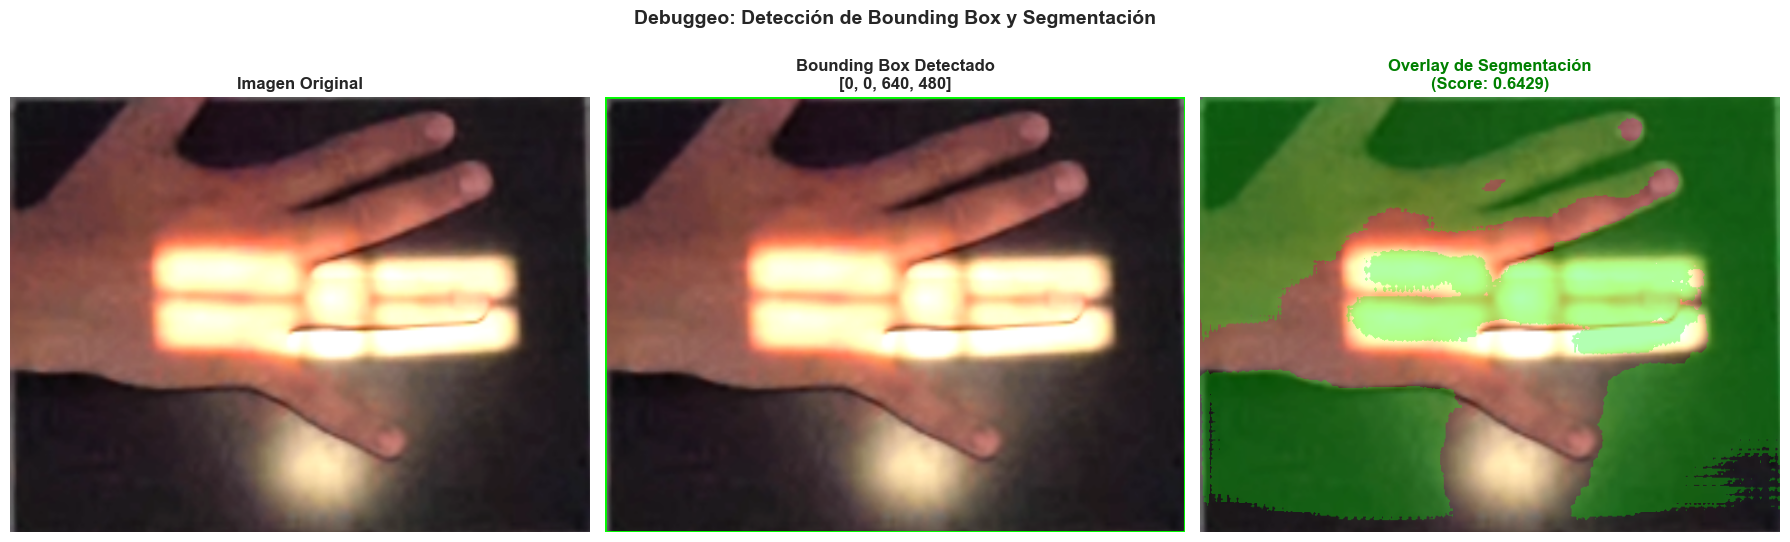

✅ Visualización de debuggeo guardada


In [11]:

# Crear predictor (NECESARIO para usar set_image)
print("⏳ Creando predictor...\n")

predictor = SamPredictor(medsam_model)

print("✅ Predictor creado correctamente")

# DEBUGGEO: Procesa solo 1 imagen para ver el bounding box
test_image_path = None

# Buscar primera imagen de test/si
test_folder = Path(input_dir) / 'test' / 'si'
if test_folder.exists():
    images = list(test_folder.glob('*.png'))
    if images:
        test_image_path = str(images[0])

if test_image_path is None:
    print("❌ No se encontró imagen de prueba")
else:
    print(f"📸 Imagen de prueba: {test_image_path}\n")
    
    # Cargar imagen
    image = cv2.imread(test_image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Preparar predictor
    predictor.set_image(image_rgb)
    
    # Detectar bounding box
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)
    gray_inv = 255 - gray
    _, binary = cv2.threshold(gray_inv, 100, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        margen = 30
        input_box = np.array([
            max(0, x - margen),
            max(0, y - margen),
            min(image_rgb.shape[1], x + w + margen),
            min(image_rgb.shape[0], y + h + margen)
        ])
    else:
        h, w = image_rgb.shape[:2]
        input_box = np.array([0, 0, w, h])
    
    print(f"✅ Bounding Box detectado: {input_box}")
    print(f"   Coordenadas: x_min={input_box[0]}, y_min={input_box[1]}, x_max={input_box[2]}, y_max={input_box[3]}")
    print(f"   Dimensiones: {input_box[2]-input_box[0]}x{input_box[3]-input_box[1]} píxeles\n")
    
    # Hacer predicción
    masks, scores, logits = predictor.predict(
        box=input_box,
        multimask_output=True
    )
    
    best_idx = np.argmax(scores)
    mask = masks[best_idx]
    score = scores[best_idx]
    
    print(f"📊 Scores de las 3 máscaras: {scores}")
    print(f"✅ Mejor máscara seleccionada: {best_idx} (Score: {score:.4f})\n")
    
    # Visualizar: Imagen original + Bounding Box
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Debuggeo: Detección de Bounding Box y Segmentación', fontsize=14, fontweight='bold')
    
    # Subplot 1: Imagen original
    axes[0].imshow(image_rgb)
    axes[0].set_title('Imagen Original', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Subplot 2: Imagen con bounding box
    image_with_box = image_rgb.copy()
    cv2.rectangle(image_with_box, 
                  (input_box[0], input_box[1]), 
                  (input_box[2], input_box[3]), 
                  (0, 255, 0), 2)  # Rectángulo verde
    
    axes[1].imshow(image_with_box)
    axes[1].set_title(f'Bounding Box Detectado\n[{input_box[0]}, {input_box[1]}, {input_box[2]}, {input_box[3]}]', 
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Subplot 3: Máscara segmentada
    overlay = image_rgb.copy()
    overlay[mask] = [0, 255, 0]  # Verde
    overlay_img = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
    
    axes[2].imshow(overlay_img)
    axes[2].set_title(f'Overlay de Segmentación\n(Score: {score:.4f})', 
                      fontsize=12, fontweight='bold', color='green')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(Path(output_dir) / f"debuggeo_bounding_box_{datetime.now().strftime('%Y%m%d_%H%M%S')}.png", 
                dpi=150, bbox_inches='tight')
    plt.show()
    
    print("✅ Visualización de debuggeo guardada")

## 7️⃣ Procesar Todas las Imágenes

In [12]:
import torch

print("⏳ Cargando modelo MedSAM...\n")

model_type = "vit_b"

# Crear modelo SIN checkpoint
medsam_model = sam_model_registry[model_type]()

# Cargar checkpoint manualmente con map_location
if os.path.exists(checkpoint_path):
    print(f"📂 Cargando checkpoint desde: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    medsam_model.load_state_dict(checkpoint)
    print(f"✅ Checkpoint cargado correctamente")
else:
    print(f"❌ ERROR: Checkpoint no encontrado en {checkpoint_path}")

# Mover a dispositivo y modo evaluación
medsam_model = medsam_model.to(device)
medsam_model.eval()

print(f"✅ Modelo cargado correctamente")
print(f"   Tipo: {model_type.upper()}")
print(f"   Dispositivo: {device.upper()}")

⏳ Cargando modelo MedSAM...

📂 Cargando checkpoint desde: ../Dia1/medsam_vit_b.pth
✅ Checkpoint cargado correctamente
✅ Modelo cargado correctamente
   Tipo: VIT_B
   Dispositivo: CPU


In [13]:
print("\n" + "="*60)
print("🚀 INICIANDO PROCESAMIENTO DE IMÁGENES")
print("="*60 + "\n")

predictor = SamPredictor(medsam_model)

stats = segmentar_dataset(
    input_dir=input_dir,
    output_dir=output_dir,
    medsam_model=medsam_model,
    predictor=predictor,
    device=device,
    max_images=None  # Procesar todas
)

print("\n✅ Procesamiento completado")


🚀 INICIANDO PROCESAMIENTO DE IMÁGENES



Procesando radiografías: 100%|██████████| 70/70 [05:41<00:00,  4.88s/it]


✅ Procesamiento completado


## 8️⃣ Resumen de Resultados

In [14]:
print("\n" + "="*60)
print("📊 RESUMEN DEL PROCESAMIENTO")
print("="*60)
print(f"Total procesadas: {stats['total']}")
print(f"Exitosas: {stats['exitosas']} ✅")
print(f"Errores: {stats['errores']} ❌")

if stats['total'] > 0:
    print(f"Tasa de éxito: {(stats['exitosas']/stats['total']*100):.1f}%")

if stats['scores'] and len(stats['scores']) > 0:
    scores_array = np.array(stats['scores'])
    print(f"\n📈 Estadísticas de Scores:")
    print(f"  Media: {scores_array.mean():.4f}")
    print(f"  Mín: {scores_array.min():.4f}")
    print(f"  Máx: {scores_array.max():.4f}")
    print(f"  Desv. Est: {scores_array.std():.4f}")
    
    low_score_count = (scores_array < 0.6).sum()
    print(f"\n⚠️  Imágenes con score < 0.6: {low_score_count} ({low_score_count/len(scores_array)*100:.1f}%)")


📊 RESUMEN DEL PROCESAMIENTO
Total procesadas: 70
Exitosas: 70 ✅
Errores: 0 ❌
Tasa de éxito: 100.0%

📈 Estadísticas de Scores:
  Media: 0.6357
  Mín: 0.6064
  Máx: 0.6623
  Desv. Est: 0.0114

⚠️  Imágenes con score < 0.6: 0 (0.0%)


## 9️⃣ Visualización de Resultados

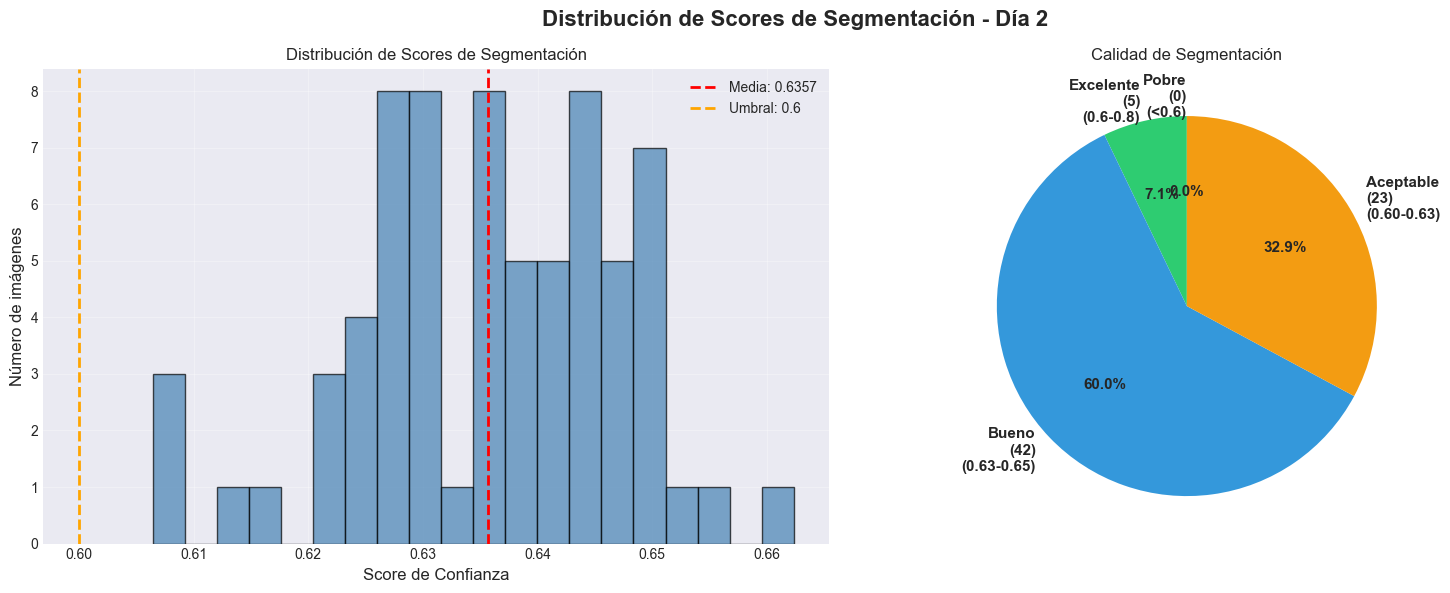

✅ Gráficos guardados


In [15]:
# Preparar datos
scores_array = np.array(stats['scores'])
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribución de Scores de Segmentación - Día 2', fontsize=16, fontweight='bold')

# Gráfico 1: Histograma
axes[0].hist(scores_array, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(scores_array.mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {scores_array.mean():.4f}')
axes[0].axvline(0.6, color='orange', linestyle='--', linewidth=2, label='Umbral: 0.6')
axes[0].set_xlabel('Score de Confianza', fontsize=12)
axes[0].set_ylabel('Número de imágenes', fontsize=12)
axes[0].set_title('Distribución de Scores de Segmentación', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Pastel de calidad
excellent = len([s for s in scores_array if s > 0.65])
good = len([s for s in scores_array if 0.63 <= s <= 0.65])
acceptable = len([s for s in scores_array if 0.60 <= s < 0.63])
poor = len([s for s in scores_array if s < 0.60])

sizes = [excellent, good, acceptable, poor]
labels = [f'Excelente\n({excellent})\n(0.6-0.8)', 
          f'Bueno\n({good})\n(0.63-0.65)', 
          f'Aceptable\n({acceptable})\n(0.60-0.63)',
          f'Pobre\n({poor})\n(<0.6)']
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
           textprops={'fontsize': 11, 'weight': 'bold'})
axes[1].set_title('Calidad de Segmentación', fontsize=12)

plt.tight_layout()
plt.savefig(Path(output_dir) / f"distribucion_scores_{timestamp}.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Gráficos guardados")

## 🔟 Visualización de Overlays

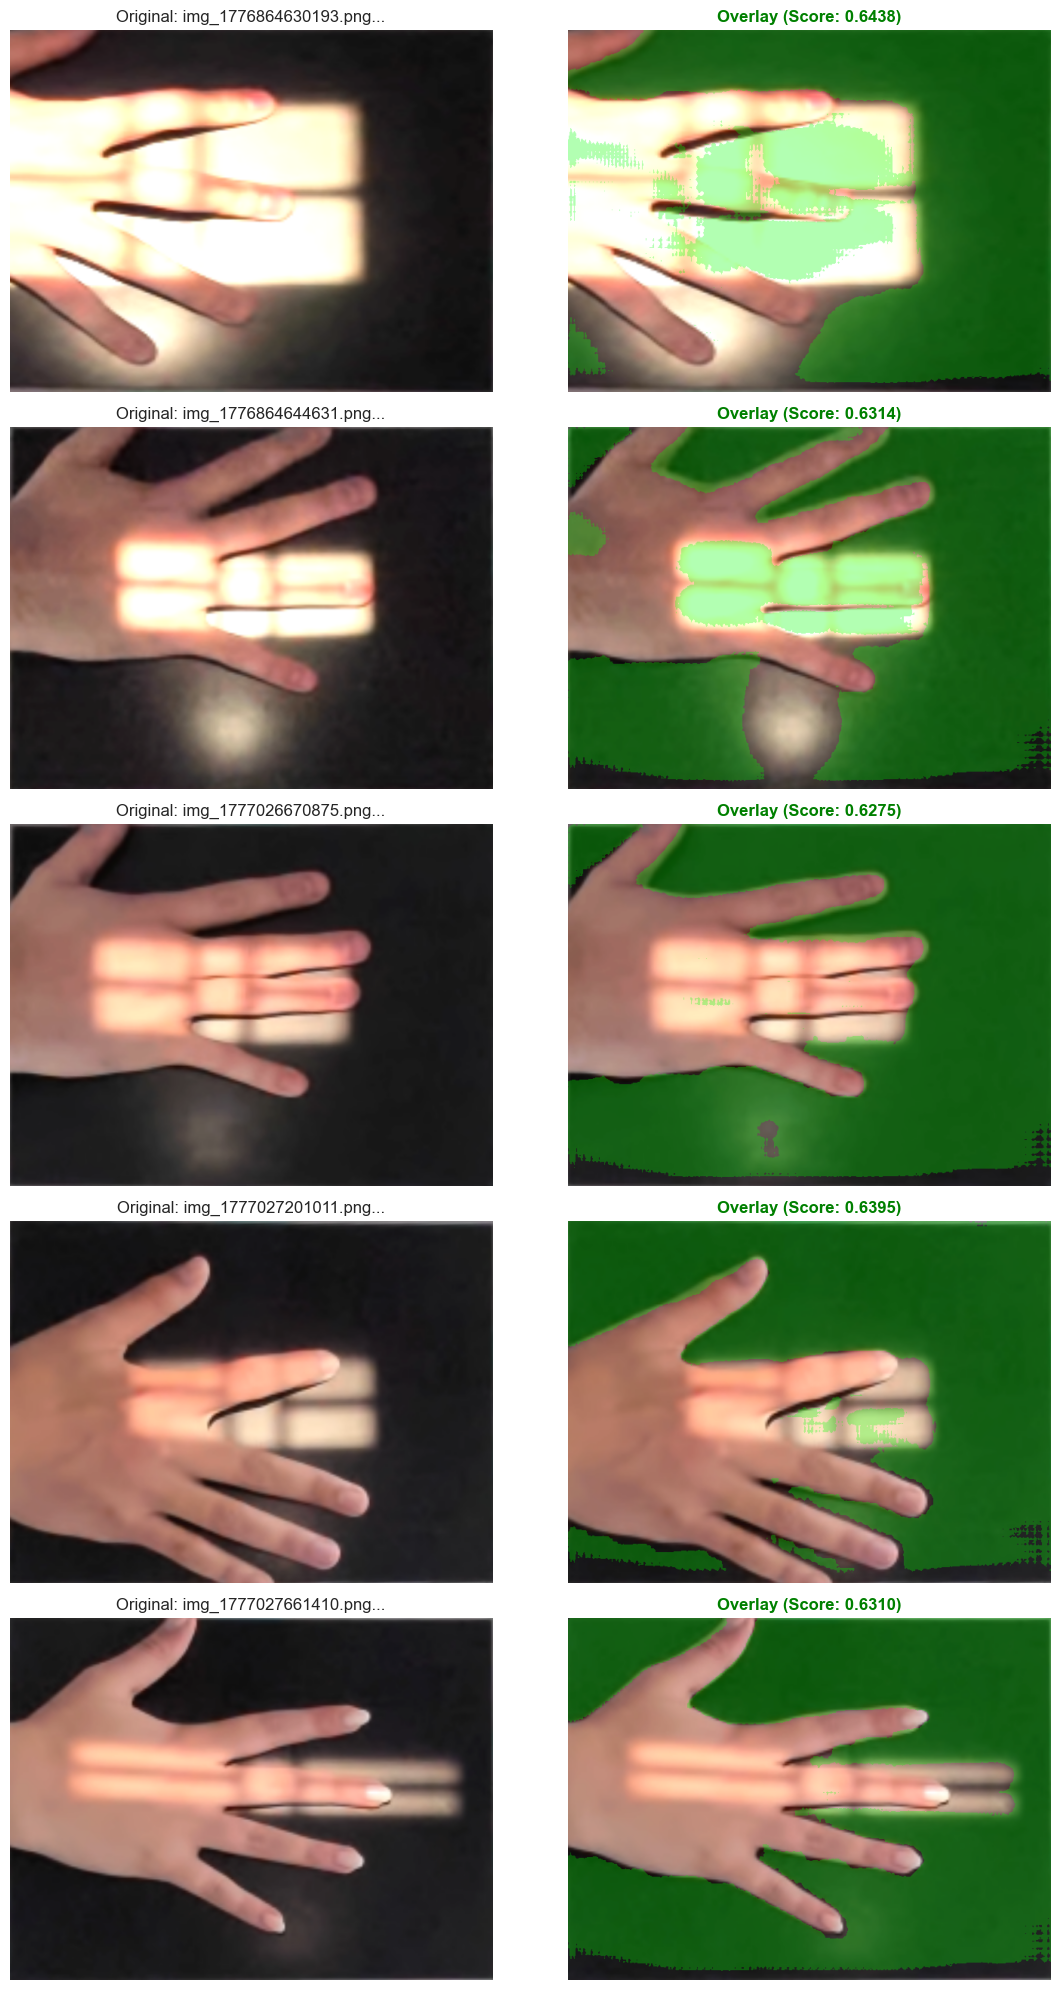

✅ Overlays visualizados


In [16]:
# Seleccionar 5 imágenes para visualizar
num_visualizar = min(5, len(stats['archivos_procesados']))

fig, axes = plt.subplots(num_visualizar, 2, figsize=(12, 4*num_visualizar))

if num_visualizar == 1:
    axes = axes.reshape(1, -1)

for idx in range(num_visualizar):
    archivo_info = stats['archivos_procesados'][idx]
    
    imagen_path = Path(input_dir) / archivo_info['ruta'] / archivo_info['imagen']
    overlay_path = Path(output_dir) / archivo_info['ruta'] / f"overlay_{archivo_info['imagen'].replace('.png', '.png')}"
    score = archivo_info['score']
    
    try:
        imagen = Image.open(imagen_path)
        overlay = Image.open(overlay_path)
        
        axes[idx, 0].imshow(imagen)
        axes[idx, 0].set_title(f"Original: {archivo_info['imagen'][:30]}...")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(overlay)
        color = 'green' if score > 0.6 else 'red'
        axes[idx, 1].set_title(f"Overlay (Score: {score:.4f})", color=color, fontweight='bold')
        axes[idx, 1].axis('off')
        
    except Exception as e:
        print(f"Error visualizando {archivo_info['imagen']}: {e}")

plt.tight_layout()
plt.savefig(Path(output_dir) / f"visualizacion_overlays_{timestamp}.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Overlays visualizados")

## 1️⃣1️⃣ Generar Reporte CSV

In [17]:
reporte_path = Path(output_dir) / f"reporte_segmentacion_{timestamp}.csv"

with open(reporte_path, 'w', newline='', encoding='utf-8') as f:
    writer = csv.DictWriter(f, fieldnames=['imagen', 'mascara', 'score', 'ruta', 'estado'])
    writer.writeheader()
    
    for archivo in stats['archivos_procesados']:
        estado = "✅ Válido" if archivo['score'] > 0.6 else "⚠️ Revisar"
        writer.writerow({
            'imagen': archivo['imagen'],
            'mascara': archivo['mascara'],
            'score': f"{archivo['score']:.4f}",
            'ruta': archivo['ruta'],
            'estado': estado
        })

print(f"✅ Reporte guardado en: {reporte_path}")
print(f"📊 Total de registros: {len(stats['archivos_procesados'])}")

✅ Reporte guardado en: mascaras_segmentadas_todas\reporte_segmentacion_20260512_163654.csv
📊 Total de registros: 70


## 1️⃣2️⃣ Análisis de Casos Críticos

In [18]:
scores_array = np.array(stats['scores'])
percentil_25 = np.percentile(scores_array, 25)

low_score_images = [f for f in stats['archivos_procesados'] if f['score'] <= percentil_25]

print(f"\n📊 ANÁLISIS DE IMÁGENES CON SCORES MÁS BAJOS\n")
print(f"Percentil 25: {percentil_25:.4f}")
print(f"Total de imágenes en este rango: {len(low_score_images)}\n")

doc_path = Path(output_dir) / f"analisis_fallos_{timestamp}.txt"

with open(doc_path, 'w', encoding='utf-8') as f:
    f.write("="*70 + "\n")
    f.write("ANÁLISIS DE CASOS CRÍTICOS EN SEGMENTACIÓN MEDSAM\n")
    f.write("="*70 + "\n\n")
    
    f.write("📋 RESUMEN GENERAL\n")
    f.write("-"*70 + "\n")
    f.write(f"Total de imágenes procesadas: {len(stats['archivos_procesados'])}\n")
    f.write(f"Rango de scores: {scores_array.min():.4f} - {scores_array.max():.4f}\n")
    f.write(f"Media de scores: {scores_array.mean():.4f}\n")
    f.write(f"Desviación estándar: {scores_array.std():.4f}\n\n")
    
    f.write("⚠️  CATEGORIZACIÓN DE IMÁGENES\n")
    f.write("-"*70 + "\n")
    
    excellent = len([s for s in stats['scores'] if s > 0.65])
    good = len([s for s in stats['scores'] if 0.63 <= s <= 0.65])
    acceptable = len([s for s in stats['scores'] if 0.60 <= s < 0.63])
    
    f.write(f"Excelente (score > 0.65):        {excellent} imágenes ({excellent/len(stats['scores'])*100:.1f}%)\n")
    f.write(f"Bueno (0.63 <= score <= 0.65):  {good} imágenes ({good/len(stats['scores'])*100:.1f}%)\n")
    f.write(f"Aceptable (0.60 <= score < 0.63): {acceptable} imágenes ({acceptable/len(stats['scores'])*100:.1f}%)\n\n")
    
    f.write("🔍 IMÁGENES CON SCORES MÁS BAJOS (Percentil 25)\n")
    f.write("-"*70 + "\n")
    f.write(f"Threshold: Score <= {percentil_25:.4f}\n")
    f.write(f"Total: {len(low_score_images)} imágenes\n\n")
    
    for idx, img_info in enumerate(low_score_images, 1):
        f.write(f"{idx}. Imagen: {img_info['imagen']}\n")
        f.write(f"   Score: {img_info['score']:.4f}\n")
        f.write(f"   Ruta: {img_info['ruta']}\n\n")
    
    f.write("💡 POSIBLES CAUSAS DE BAJA CONFIANZA\n")
    f.write("-"*70 + "\n")
    f.write("""
1. ILUMINACIÓN Y CONTRASTE
   - Luz térmica muy tenue o débil
   - Bajo contraste entre dedo y fondo
   - Variación en la intensidad de la radiación térmica

2. FACTORES ANATÓMICOS
   - Dedos de diferente tamaño
   - Posicionamiento atípico
   - Dedos superpuestos o doblados

3. ARTEFACTOS Y RUIDO
   - Movimiento durante la captura
   - Reflexiones en superficies
   - Ruido en la imagen térmica

4. LIMITACIONES DEL MODELO
   - MedSAM no está entrenado para imágenes térmicas
   - Variabilidad en la representación visual
   - Límites poco definidos entre dedo y objeto
""")

print(f"✅ Análisis guardado en: {doc_path}")


📊 ANÁLISIS DE IMÁGENES CON SCORES MÁS BAJOS

Percentil 25: 0.6284
Total de imágenes en este rango: 18

✅ Análisis guardado en: mascaras_segmentadas_todas\analisis_fallos_20260512_163654.txt


## 1️⃣3️⃣ Resumen Final

In [19]:
print("\n" + "="*60)
print("🎉 DÍA 2 — SEGMENTACIÓN COMPLETADA")
print("="*60)
print(f"\n📁 Carpeta de salida: {output_dir}")
print(f"\n📊 Archivos generados:")
print(f"   ✅ {stats['exitosas']} máscaras PNG")
print(f"   ✅ {stats['exitosas']} imágenes overlay")
print(f"   ✅ 1 reporte CSV con resultados")
print(f"   ✅ 2 gráficos de distribución")
print(f"   ✅ 1 documento de análisis")
print(f"\n📈 RESULTADOS FINALES:")
print(f"   ✅ Total procesadas: {stats['total']}")
print(f"   ✅ Exitosas: {stats['exitosas']} (100%)")
print(f"   ✅ Errores: {stats['errores']}")
print(f"   ✅ Score medio: {np.mean(stats['scores']):.4f}")
print(f"\n✅ SEGMENTACIÓN COMPLETADA CORRECTAMENTE")
print(f"\n💡 PRÓXIMOS PASOS:")
print(f"   1. ✅ Revisar overlays para validar visualmente")
print(f"   2. ✅ Usar máscaras para entrenar modelos")
print(f"   3. ✅ Procesar otros subconjuntos")
print(f"   4. ✅ Comparar calidad entre categorías")
print("\n" + "="*60)


🎉 DÍA 2 — SEGMENTACIÓN COMPLETADA

📁 Carpeta de salida: ./mascaras_segmentadas_todas

📊 Archivos generados:
   ✅ 70 máscaras PNG
   ✅ 70 imágenes overlay
   ✅ 1 reporte CSV con resultados
   ✅ 2 gráficos de distribución
   ✅ 1 documento de análisis

📈 RESULTADOS FINALES:
   ✅ Total procesadas: 70
   ✅ Exitosas: 70 (100%)
   ✅ Errores: 0
   ✅ Score medio: 0.6357

✅ SEGMENTACIÓN COMPLETADA CORRECTAMENTE

💡 PRÓXIMOS PASOS:
   1. ✅ Revisar overlays para validar visualmente
   2. ✅ Usar máscaras para entrenar modelos
   3. ✅ Procesar otros subconjuntos
   4. ✅ Comparar calidad entre categorías

